In [35]:
import json
from python.component_search.service import search_mpn_part

result = search_mpn_part("TAS2770RJQR-1", limit=10)
print(json.dumps(result, indent=2))

{
  "success": true,
  "query": "TAS2770RJQR-1",
  "terms": [
    "tas2770rjqr-1"
  ],
  "coreTerms": [],
  "optionalTerms": [
    "tas2770rjqr-1"
  ],
  "limit": 10,
  "offset": 0,
  "count": 1,
  "dbPath": "/root/workspace/KiCAD_MCP/part_lib/jlcpcb-components.sqlite3",
  "results": [
    {
      "mpn": "TAS2770RJQR-1",
      "package": "VQFN-HR (RJQ) 26-pin (4.0mm x 3.5mm)",
      "footprint": "Operational_Amplifier_Comparator:VQFN-HR-26_L4.0-W3.5_TAS2770RJQR",
      "library": "Audio_Amplifier",
      "class": "Audio_Amplifier",
      "datasheet": "datasheets/raw_files/3cfaa946437a458dbecc62a634cb0e0e.pdf",
      "joints": 0,
      "score": -8.011660473178965,
      "attributes": {
        "Type": "Digital input mono Class-D audio amplifier",
        "Output Power": "20W into 4\u03a9 at 16V (THD=1%)",
        "Supply Voltage (VBAT)": "4.5V to 16V",
        "Digital Audio Interfaces": "I2S/TDM, PDM",
        "Speaker Sensing": "Integrated voltage and current sense (I/V)"
      }
    

In [ ]:
from python.component_search.service import search_datasheet
result = search_datasheet("R", "Devices")

print(result)

In [ ]:
import sqlite3
import pandas as pd  # optional but handy

path = "/root/workspace/KiCAD_MCP/part_lib/jlcpcb-components.sqlite3"
with sqlite3.connect(path) as conn:
    df = pd.read_sql_query("SELECT * FROM v_components_search;", conn)

# df now contains the entire view; drop pandas if you prefer to iterate over conn.execute(...)


In [ ]:
df.head(3)

In [ ]:
mask = (df["symbol_lib"] == 1) #& df["spice_model"].notna()
filtered = df.loc[mask]


In [ ]:
len(filtered)

In [ ]:
len(filtered[filtered["class"]=='MOSFETs'])

In [ ]:
# len(list(schematic.symbol))              # should increase by 1
# any(sym.property.Reference.value == "Q1" for sym in schematic.symbol)

In [ ]:
import json, sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() / "python"))
from commands.database_tools.library_schematic import LibraryManager
result = LibraryManager.get_symbol_pinout({
    "library": "Power_Management_ICs",
    "symbol": "IP2312",
})
print(json.dumps(result, indent=2))

In [48]:
import json
from python.commands.database_tools.symbol_builders import build_symbol_from_json

file_path = "test_cases/test_audio_amplifier/symbols/94e6638093ff4ff4bc5663dba417b306.json"

lib = "Triode_MOS_Tube_Transistor"

with open(file_path, "r") as f:
    symbol_json = json.load(f)

name = "STB140NF55T4"
print(name)

sexp = build_symbol_from_json(symbol_json)

STB140NF55T4


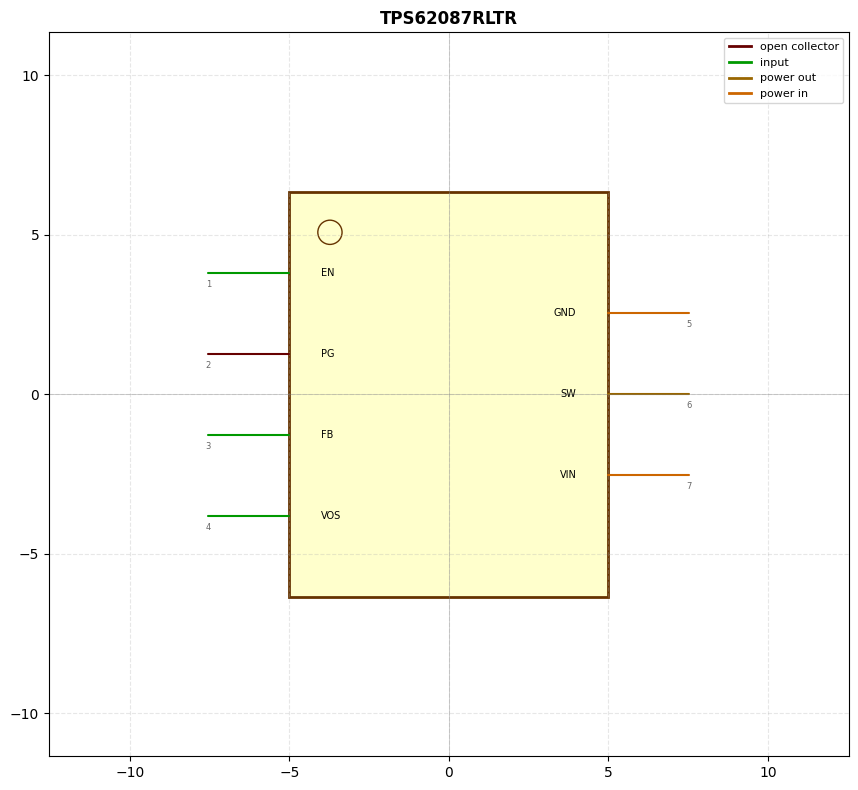

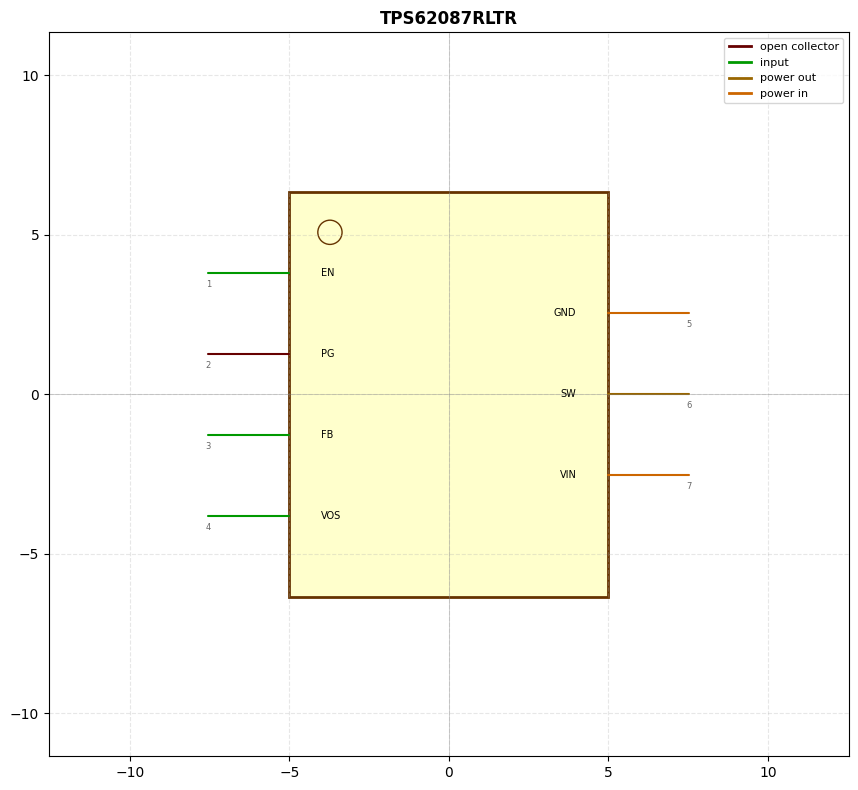

In [45]:
from python.commands.database_tools.symbol_visualizer import visualize_symbol, visualize_by_mpn

# Visualize from database by MPN
# visualize_by_mpn("TPS54531DDA-1", "Power_Supply_Chip", show=False)
visualize_symbol(sexp, show=False)



In [46]:
from python.commands.database_tools.library_schematic import LibraryManager

result = LibraryManager.add_symbol_entry({
    "mpn": name,
    "library": lib,
    "sexp": sexp,
    "overwrite": True  # This will replace existing entry
})


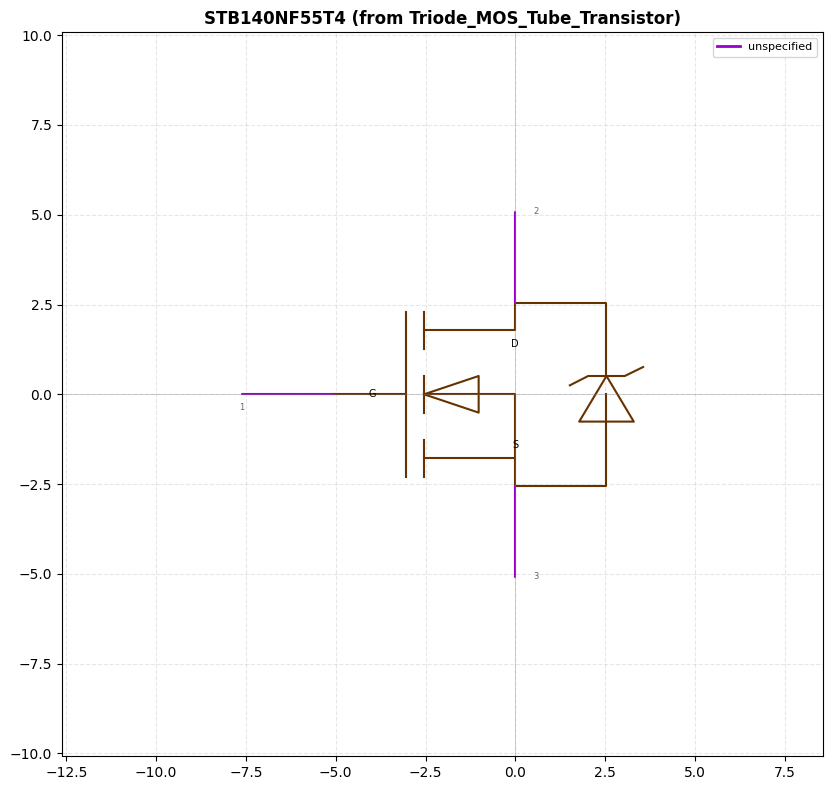

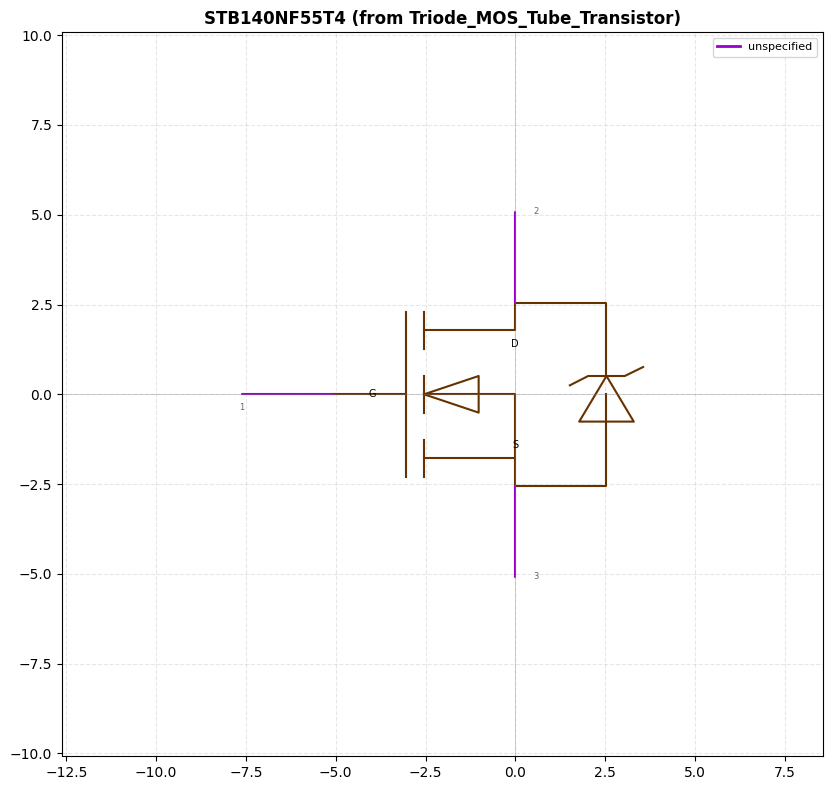

In [49]:
visualize_by_mpn(name, lib, show=False)

9
TPS62087RLTR Power_Supply_Chip


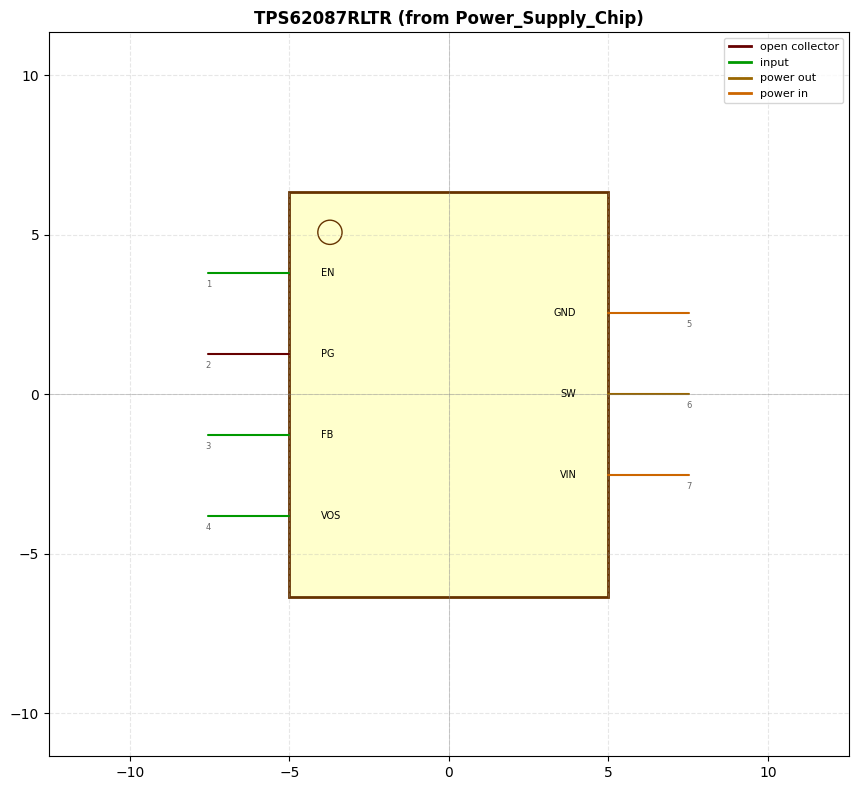

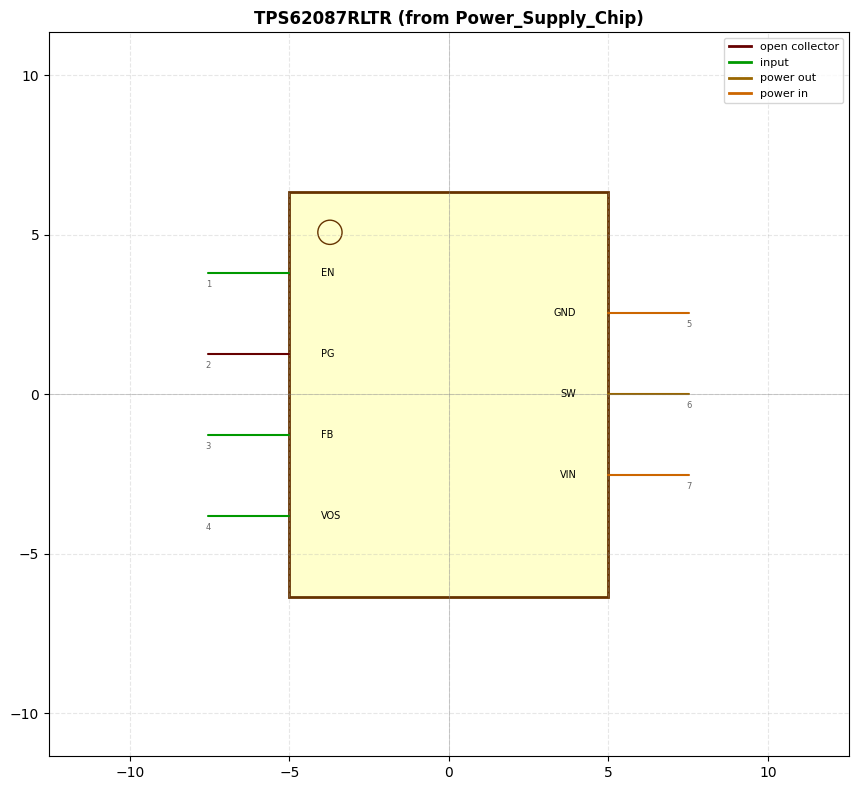

In [59]:
import sqlite3
with sqlite3.connect("datasheets/datasheet_tracker") as conn:
    conn.row_factory = sqlite3.Row
    rows = conn.execute("SELECT * FROM datasheet_tracker").fetchall()
    entries = [dict(row) for row in rows]
print(len(entries))

idx = 8
name = entries[idx]["symbol_name"]
lib = entries[idx]["library"]
print(name, lib)
visualize_by_mpn(name, lib, show=False)